In [1]:
import pandas as pd 

# Exemplo de dataset simulado

# data = pd.DataFrame({
#     "tempo": [5, 6, 6, 2, 4, 3, 8, 10],
#     "evento": [1, 0, 1, 1, 0, 1, 0, 1],  # 1 = evento aconteceu, 0 = censurado
#     "idade": [50, 60, 45, 70, 55, 65, 80, 40],
#     "pressao": [120, 130, 110, 140, 135, 150, 160, 125],
# }).sort_values("tempo")

link_csv = r'D:\cox-models-sudden-death\01_Dataset\dados_csv_info_definitions\subject-info_formatado.csv'



df = pd.read_csv(link_csv, delimiter=';')

In [2]:
print(f'class 0: {df.query('`Cause of death` == 0').shape[0]}')
print(f'class 1: {df.query('`Cause of death` == 1').shape[0]}')
print(f'class 3: {df.query('`Cause of death` == 3').shape[0]}')
print(f'class 6: {df.query('`Cause of death` == 6').shape[0]}')
print(f'class 7: {df.query('`Cause of death` == 7').shape[0]}')

class 0: 726
class 1: 61
class 3: 94
class 6: 100
class 7: 11


Causa da morte E Causa da morte
- 0: sobrevivente;
- 1: morte não cardíaca;
- 3: SCD;
- 6-7: Morte por falha da bomba;
- Conforme data de encerramento do estudo
- A SCD é causada por arritmias no coração

A arritmia mais comum associada à Morte Súbita Cardíaca é a fibrilação ventricular. Essas arritmias cardíacas são impulsos de disparo rápido das câmaras inferiores do coração (ventrículos).

In [3]:
# qrs_duration = dados['QRS duration (ms)']               # Duração do complexo QRS
# qt_interval = dados['QT interval (ms)']                 # Intervalo QT
# hrv = dados['SDNN (ms)']                                # Variabilidade da frequência cardíaca

idade = df['Age']                                      # Idade dos pacientes
genero = df['Gender (male=1)']                          # 0 = mulher, 1 = homem


tempo = df['Follow-up period from enrollment (days)'] # Tempo até o evento ou censura (dias)
evento = df['Cause of death']                         # 1 = morte cardíaca, 0 = censurado


In [4]:
dados = pd.DataFrame({
    "tempo": tempo.values,
    "evento": evento.values,
    "idade": idade.values,
    "genero": genero.values}).sort_values("tempo")


dados

,tempo,evento,idade,genero
717,33,3,57,1
479,37,3,80,0
648,43,3,69,1
762,46,1,66,0
431,48,7,71,1
...,...,...,...,...
4,2043,0,70,1
3,2044,0,56,0
2,2044,0,69,1
1,2045,0,58,1


In [5]:
# 0 sobreviventes, censurados 1 (6 arritmia)
dados = dados.query('(evento == 0) or (evento == 6)')

# lipando os indices e ordenando
dados = dados.reset_index(drop=True).sort_values("tempo")

# passando evento tipo 6 para 1 (considerando como evento)
dados['evento'] = dados['evento'].replace(6, 1)

In [6]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
Index: 826 entries, 0 to 825
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   tempo   826 non-null    int64
 1   evento  826 non-null    int64
 2   idade   826 non-null    int64
 3   genero  826 non-null    int64
dtypes: int64(4)
memory usage: 32.3 KB



--- Regressão de Cox com 'lifelines' ---


<lifelines.CoxPHFitter: fitted with 826 total observations, 726 right-censored observations>
             duration col = 'tempo'
                event col = 'evento'
      baseline estimation = breslow
   number of observations = 826
number of events observed = 100
   partial log-likelihood = -641.41
         time fit was run = 2025-09-10 01:55:28 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
idade      0.06      1.07      0.01            0.04            0.09                1.04                1.09
genero     0.43      1.54      0.24           -0.03            0.89                0.97                2.44

           cmp to    z      p  -log2(p)
covariate                              
idade        0.00 5.88 <0.005     27.83
genero       0.00 1.82   0.07      3.86
---
Concordance = 0.67
Partial AIC = 1286.81
log-likelihood ratio test = 41.49 on 2 df
-log2(p) of ll-ratio test = 29.93

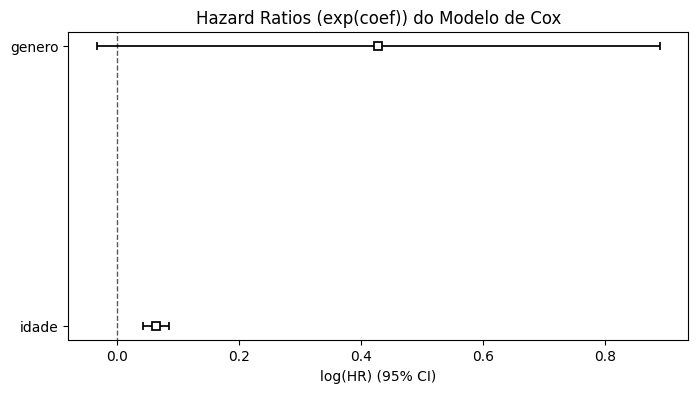

In [9]:
from lifelines import CoxPHFitter
import matplotlib.pyplot as plt

print("\n--- Regressão de Cox com 'lifelines' ---")

# A Regressão de Cox usa todas as colunas: tempo, evento e as covariáveis
cph = CoxPHFitter()

# Ajustar o modelo aos dados
# duration_col='tempo', event_col='evento', e as outras colunas são usadas como covariáveis
cph.fit(dados, duration_col='tempo', event_col='evento')

# Exibir o resumo do modelo
cph.print_summary()

# Plotar os coeficientes (Hazard Ratios)
plt.figure(figsize=(8, 4))
cph.plot()
plt.title("Hazard Ratios (exp(coef)) do Modelo de Cox")
plt.show()

Regressão de cox com dados multimplos

- Idade
- Genero 

In [10]:
import pandas as pd
from lifelines import CoxPHFitter


# ----------------------------------------------------
# PASSO 1: ANÁLISE UNIVARIADA (TRIAGEM)
# ----------------------------------------------------
print("--- PASSO 1: Análise Univariada de Cox (Screening) ---\n")

covariates = [ 'idade', 'genero']
univariate_results = {}

for var in covariates:
    # Criamos um sub-dataframe com apenas as colunas necessárias para cada modelo
    df_temp = dados[['tempo', 'evento', var]]
    
    cph = CoxPHFitter()
    cph.fit(df_temp, duration_col='tempo', event_col='evento')
    
    # Guardamos o p-valor para decidir se a variável é promissora
    p_value = cph.summary.loc[var, 'p']
    univariate_results[var] = p_value
    
    print(f"Resultado Univariado para '{var}': p-valor = {p_value:.4f}")

# Decisão: Selecionar variáveis com p < 0.20 para o próximo passo
variáveis_promissoras = [var for var, p in univariate_results.items() if p < 0.20]
print(f"\nVariáveis promissoras selecionadas (p < 0.20): {variáveis_promissoras}")


# ----------------------------------------------------
# PASSO 2: ANÁLISE MULTIVARIADA (MODELO FINAL)
# ----------------------------------------------------
print("\n\n--- PASSO 2: Análise Multivariada de Cox (Modelo Final) ---")

# Selecionamos apenas as colunas promissoras, mais tempo e evento
df_final_model = dados[['tempo', 'evento'] + variáveis_promissoras]

cph_multi = CoxPHFitter()
cph_multi.fit(df_final_model, duration_col='tempo', event_col='evento')

print("Resumo do modelo multivariado final:")
cph_multi.print_summary()

--- PASSO 1: Análise Univariada de Cox (Screening) ---

Resultado Univariado para 'idade': p-valor = 0.0000
Resultado Univariado para 'genero': p-valor = 0.2989

Variáveis promissoras selecionadas (p < 0.20): ['idade']


--- PASSO 2: Análise Multivariada de Cox (Modelo Final) ---
Resumo do modelo multivariado final:


<lifelines.CoxPHFitter: fitted with 826 total observations, 726 right-censored observations>
             duration col = 'tempo'
                event col = 'evento'
      baseline estimation = breslow
   number of observations = 826
number of events observed = 100
   partial log-likelihood = -643.18
         time fit was run = 2025-09-10 02:00:10 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
idade      0.06      1.06      0.01            0.04            0.08                1.04                1.09

           cmp to    z      p  -log2(p)
covariate                              
idade        0.00 5.69 <0.005     26.25
---
Concordance = 0.66
Partial AIC = 1288.35
log-likelihood ratio test = 37.94 on 1 df
-log2(p) of ll-ratio test = 30.35